
# Project 2 - Drosophila Brain scRNA-seq

## 1. Imports and paths

In [1]:
import sys
from pathlib import Path

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"
RESULT_DIR = PROJECT_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(FIG_DIR)

print("Project:", PROJECT_DIR.resolve())
print("Data:", DATA_DIR.resolve())
print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__)

Project: D:\bmp\sc_project2_drosophila_brain
Data: D:\bmp\sc_project2_drosophila_brain\data
Scanpy: 1.12.4
AnnData: 0.13.3.post0


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\3110024492.py:14: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)
C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\3110024492.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)
C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\3110024492.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("AnnData:", ad.__version__)


## 2. Verify all eight sample folders

In [2]:
expected_samples = {
    "Female_Cocaine_1", "Female_Cocaine_2",
    "Female_Sucrose_1", "Female_Sucrose_2",
    "Male_Cocaine_1", "Male_Cocaine_2",
    "Male_Sucrose_1", "Male_Sucrose_2"
}

assert DATA_DIR.exists(), f"Data folder not found: {DATA_DIR}"

sample_dirs = sorted([
    p for p in DATA_DIR.iterdir()
    if p.is_dir() and (
        (p / "matrix.mtx").exists() or
        (p / "matrix.mtx.gz").exists()
    )
])

found_samples = {p.name for p in sample_dirs}

print(f"Found {len(sample_dirs)} sample folders:")
for p in sample_dirs:
    print("  ", p.name)

missing = expected_samples - found_samples
unexpected = found_samples - expected_samples

print("\nMissing:", sorted(missing))
print("Unexpected:", sorted(unexpected))

assert found_samples == expected_samples, "Sample folder check failed."
print("\n✓ All 8 expected samples found.")

Found 8 sample folders:
   Female_Cocaine_1
   Female_Cocaine_2
   Female_Sucrose_1
   Female_Sucrose_2
   Male_Cocaine_1
   Male_Cocaine_2
   Male_Sucrose_1
   Male_Sucrose_2

Missing: []
Unexpected: []

✓ All 8 expected samples found.


## 3. Robust 10x loader

In [3]:
import gzip
from scipy.io import mmread


def find_file(folder, base):
    plain = folder / base
    gz = folder / (base + ".gz")
    if plain.exists():
        return plain
    elif gz.exists():
        return gz
    else:
        raise FileNotFoundError(f"Could not find {base} or {base}.gz in {folder}")


def read_table(path):
    """Parse a 10x barcodes/features file, tolerating either tab- or
    space-delimited columns (this GEO deposit uses spaces, not tabs).
    Uses split(None, 2) so a two-word feature type like "Gene Expression"
    stays in a single column instead of being split apart."""
    opener = gzip.open if str(path).endswith(".gz") else open
    rows = []
    with opener(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            rows.append(line.split(None, 2))
    return pd.DataFrame(rows)


def load_10x_robust(folder):
    matrix_file = find_file(folder, "matrix.mtx")
    barcode_file = find_file(folder, "barcodes.tsv")
    feature_file = find_file(folder, "features.tsv")

    X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes
    n_cells, n_genes = X.shape

    barcodes = read_table(barcode_file)
    features = read_table(feature_file)

    if len(barcodes) != n_cells:
        raise ValueError(f"{folder.name}: {len(barcodes)} barcodes but {n_cells} cells in matrix")
    if len(features) != n_genes:
        raise ValueError(f"{folder.name}: {len(features)} features but {n_genes} genes in matrix")

    if features.shape[1] >= 2:
        gene_ids = features.iloc[:, 0].astype(str).to_numpy()
        gene_symbols = features.iloc[:, 1].astype(str).to_numpy()
    else:
        gene_ids = features.iloc[:, 0].astype(str).to_numpy()
        gene_symbols = gene_ids.copy()

    empty_symbols = pd.Series(gene_symbols).str.strip().eq("").to_numpy()
    gene_symbols[empty_symbols] = gene_ids[empty_symbols]

    cell_names = barcodes.iloc[:, 0].astype(str).to_numpy()
    obs = pd.DataFrame(index=cell_names)
    var = pd.DataFrame({"gene_ids": gene_ids, "gene_symbols": gene_symbols}, index=gene_symbols)

    a = ad.AnnData(X=X, obs=obs, var=var)
    a.var_names_make_unique()
    return a

## 4. Load and merge all eight samples

In [4]:
adatas = {}
for sample_path in sample_dirs:
    sample_name = sample_path.name
    sex, treatment, replicate = sample_name.split("_")

    a = load_10x_robust(sample_path)
    a.obs["sample"] = sample_name
    a.obs["sex"] = sex
    a.obs["treatment"] = treatment
    a.obs["replicate"] = replicate
    a.obs["condition"] = f"{sex}_{treatment}"
    adatas[sample_name] = a
    print(f"Loaded {sample_name}: {a.n_obs:,} cells x {a.n_vars:,} genes")

adata = ad.concat(adatas, label="sample_batch", index_unique="-", join="outer", fill_value=0)
adata.var_names_make_unique()
for col in ["sample", "sex", "treatment", "replicate", "condition"]:
    adata.obs[col] = adata.obs[col].astype("category")

print(f"\nMerged: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
adata.write(RESULT_DIR / "adata_merged_raw.h5ad")
print("✓ Raw merged checkpoint saved.")

C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\1692192857.py:37: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes


Loaded Female_Cocaine_1: 13,072 cells x 17,481 genes


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\1692192857.py:37: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes


Loaded Female_Cocaine_2: 9,367 cells x 17,481 genes


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\1692192857.py:37: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes


...

Loaded Male_Cocaine_2: 11,124 cells x 17,481 genes


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\1692192857.py:37: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes


Loaded Male_Sucrose_1: 13,193 cells x 17,481 genes


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\1692192857.py:37: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  X = mmread(matrix_file).tocsr().T  # genes x cells -> cells x genes


Loaded Male_Sucrose_2: 11,033 cells x 17,481 genes

Merged: 88,991 cells x 17,481 genes
✓ Raw merged checkpoint saved.


## 5. Quality control

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("mt:")
adata.var["ribo"] = adata.var_names.str.startswith(("RpS", "RpL"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)

# Sanity check: catches an unfixed/regressed loader immediately instead of
# silently producing a flat mitochondrial percentage downstream.
n_mt_genes = int(adata.var["mt"].sum())
mt_std = adata.obs["pct_counts_mt"].std()
print(f"Mitochondrial genes found: {n_mt_genes}")
print(f"pct_counts_mt std: {mt_std:.4f}")
assert n_mt_genes > 0, "No mitochondrial genes matched 'mt:' prefix - check gene name parsing."
assert mt_std > 0, "pct_counts_mt has zero variance - QC metrics look wrong, check the loader."

display(adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"]].describe())

Mitochondrial genes found: 24
pct_counts_mt std: 0.9624


,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,88991.000000,88991.000000,88991.000000,88991.000000
mean,1011.294288,2585.117562,0.417273,8.074721
std,589.526306,3316.111743,0.962399,3.327207
min,84.000000,500.000000,0.000000,0.273723
25%,572.000000,920.000000,0.096200,5.997392
50%,869.000000,1666.000000,0.229075,7.608696
75%,1271.000000,2959.000000,0.467290,9.523810
max,5850.000000,142279.000000,82.421227,48.702830


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\3588951206.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


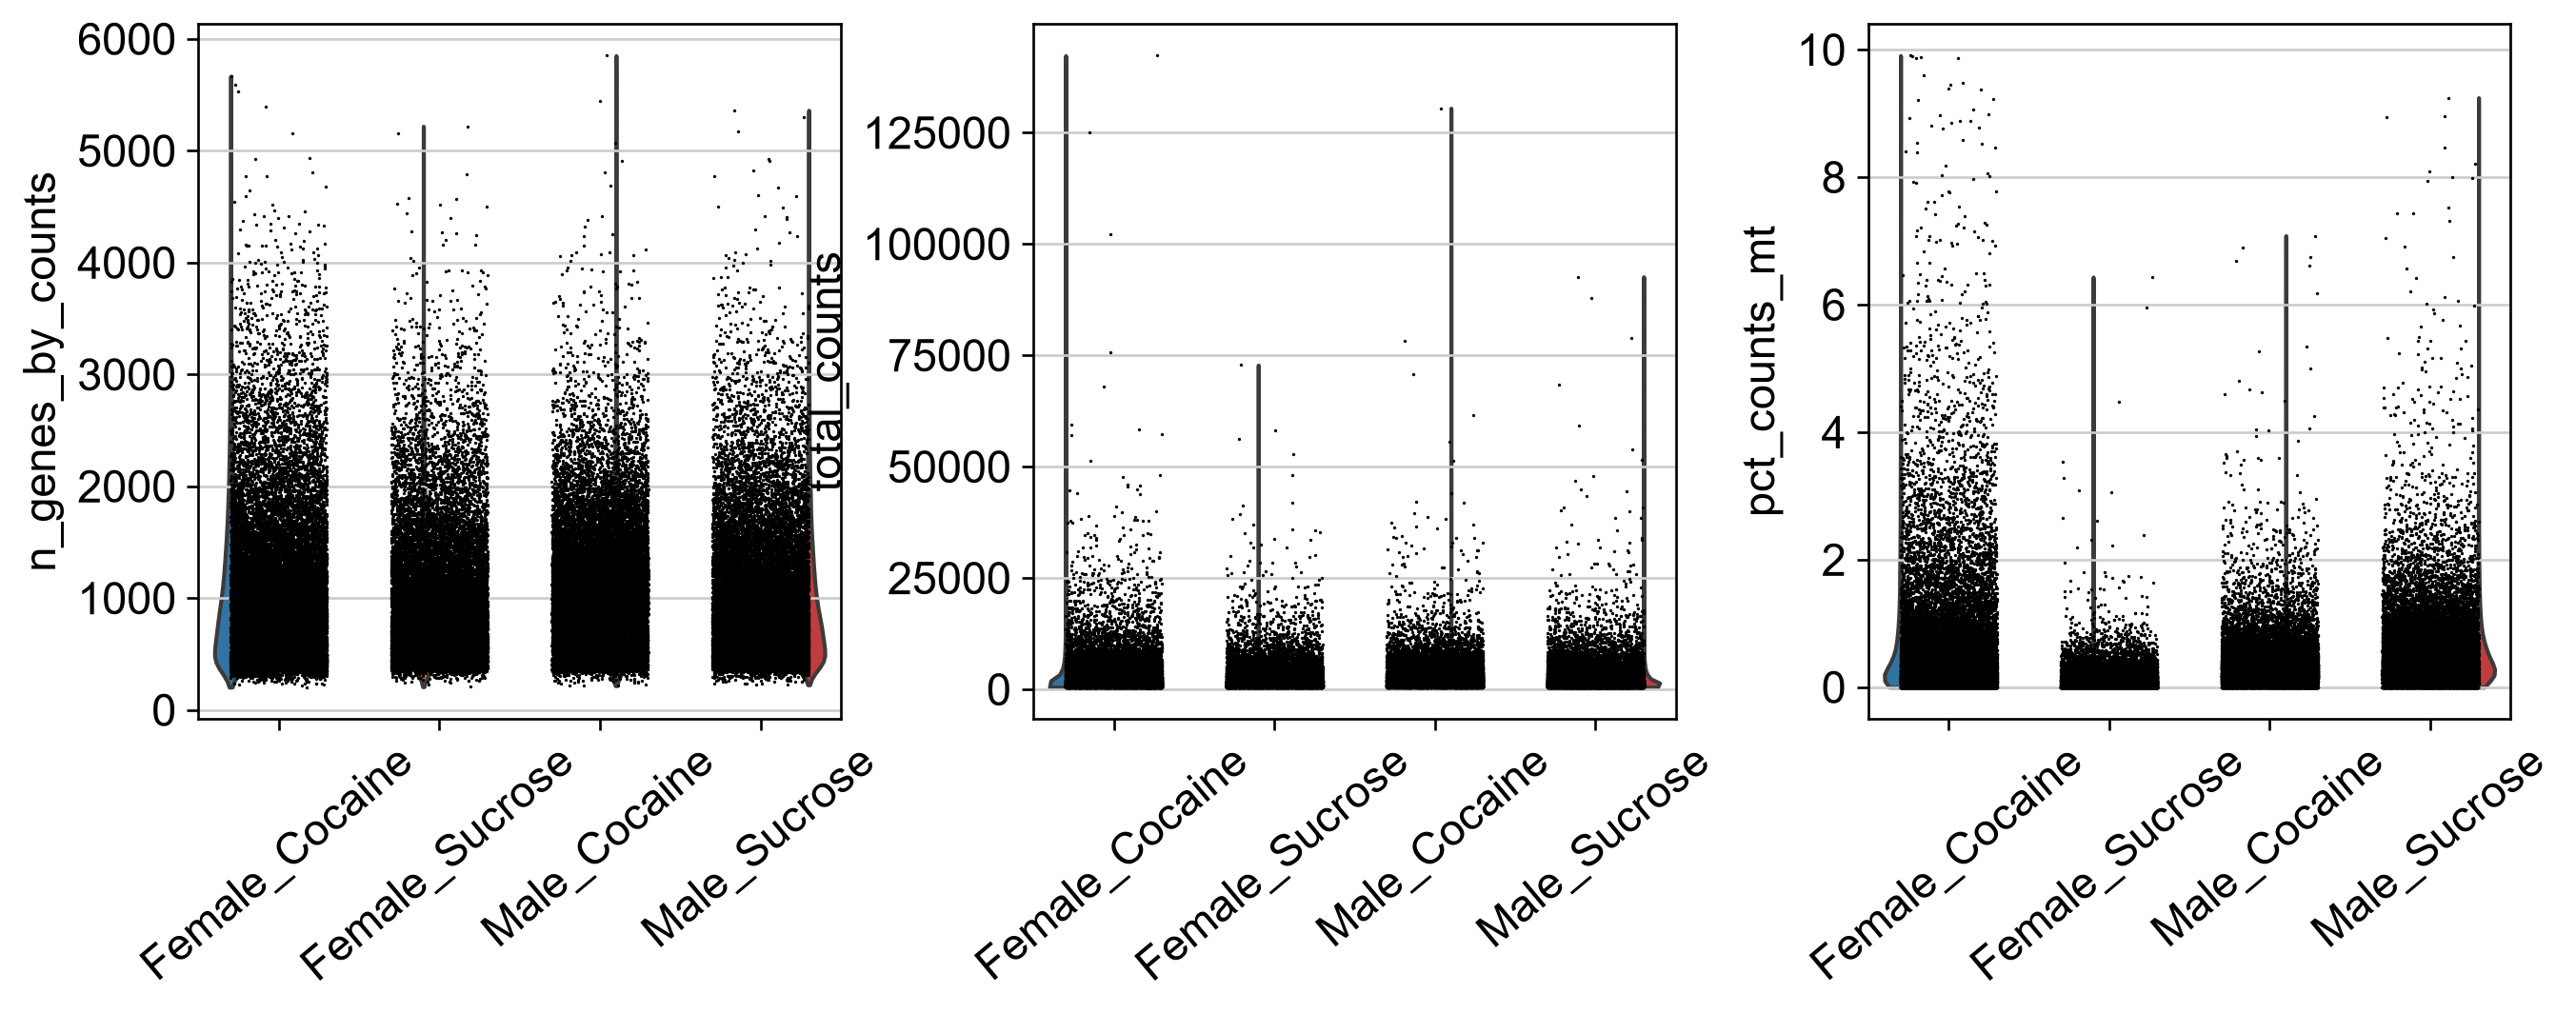

In [24]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="condition",
    jitter=0.3,
    multi_panel=True,
    rotation=40,
    save="_QC_condition.png",
)

## 6. Apply QC filters

In [7]:
before_cells, before_genes = adata.n_obs, adata.n_vars

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 10].copy()

print(f"Cells: {before_cells:,} -> {adata.n_obs:,}")
print(f"Genes: {before_genes:,} -> {adata.n_vars:,}")

qc_summary = pd.DataFrame({"stage": ["before_QC", "after_QC"],
                            "cells": [before_cells, adata.n_obs],
                            "genes": [before_genes, adata.n_vars]})
display(qc_summary)
qc_summary.to_csv(RESULT_DIR / "QC_summary.csv", index=False)

filtered out 11 cells that have less than 200 genes expressed
filtered out 4340 genes that are detected in less than 3 cells
Cells: 88,991 -> 88,923
Genes: 17,481 -> 13,141


,stage,cells,genes
0,before_QC,88991,17481
1,after_QC,88923,13141


## 7. Normalize and find highly variable genes

normalizing counts per cell
    finished (0:00:11)
extracting highly variable genes
    finished (0:00:17)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 2000


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\188095536.py:9: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.highly_variable_genes(adata, save="_HVGs.png")


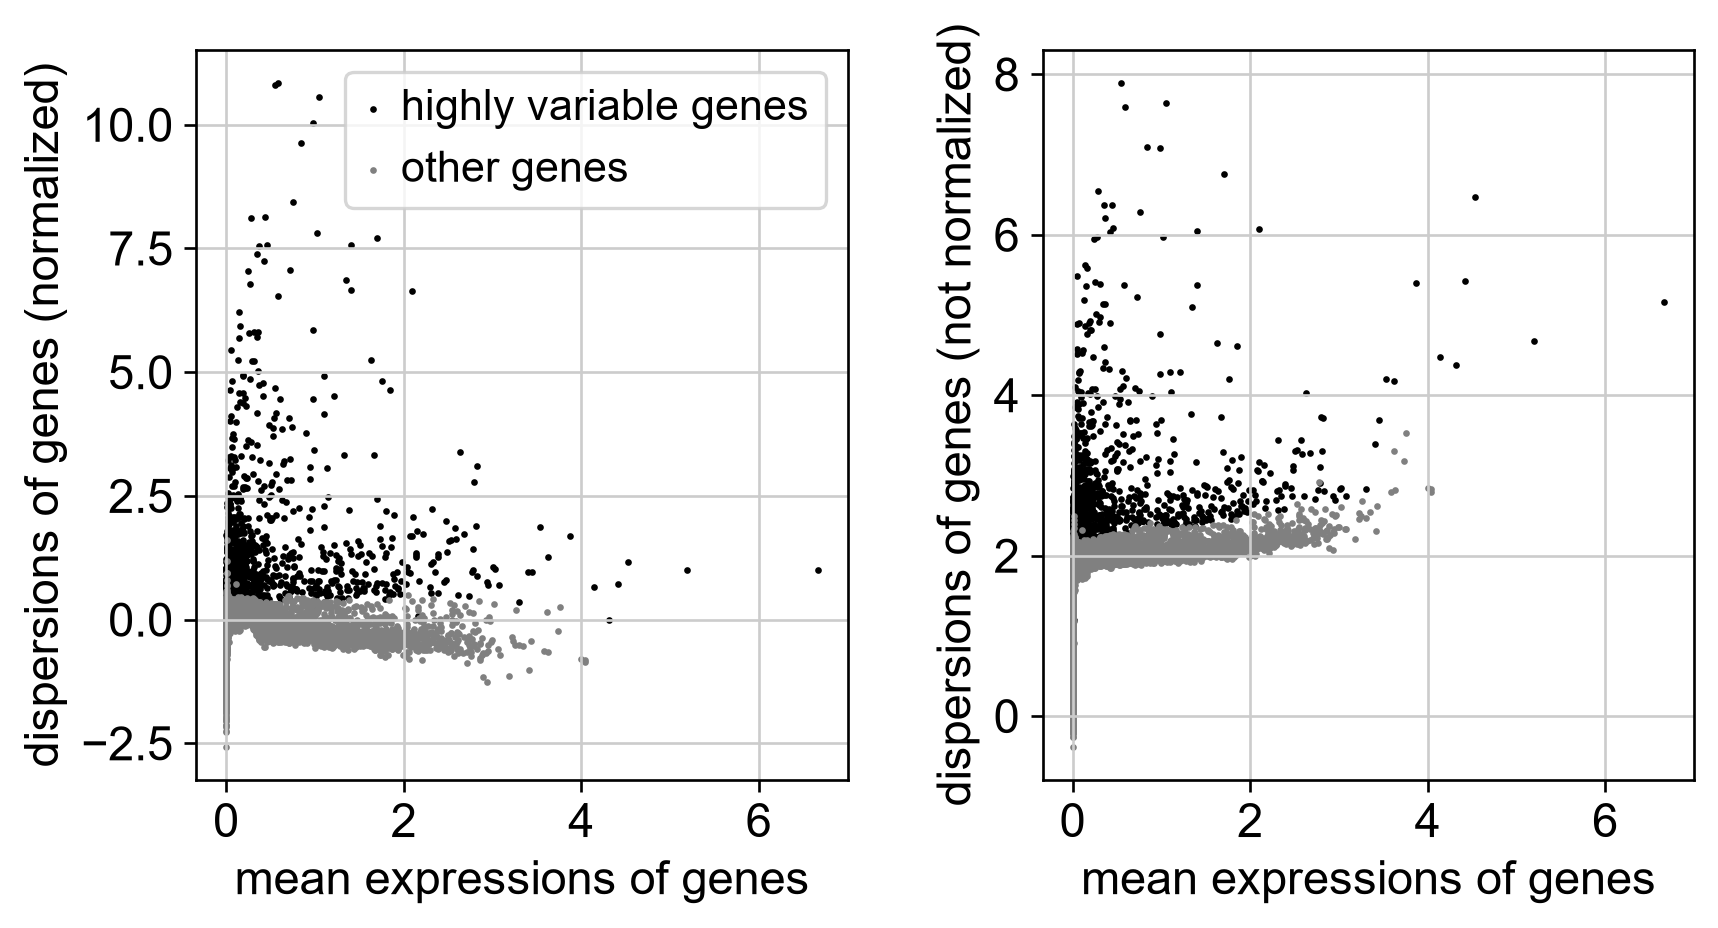

In [8]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # full log-normalized data, kept for markers/DE later

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
print("Highly variable genes:", int(adata.var["highly_variable"].sum()))
sc.pl.highly_variable_genes(adata, save="_HVGs.png")

## 8. Regression and scaling (memory-safe: HVG subset only)

In [9]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(f"HVG subset for PCA: {adata_hvg.n_obs:,} cells x {adata_hvg.n_vars:,} genes")

sc.pp.regress_out(adata_hvg, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata_hvg, max_value=10)
print("✓ Regressed and scaled on the HVG subset.")

HVG subset for PCA: 88,923 cells x 2,000 genes
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


D:\bmp\sc_project2_drosophila_brain\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:660: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
D:\bmp\sc_project2_drosophila_brain\.venv\Lib\site-packages\scanpy\preprocessing\_simple.py:660: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:18)
✓ Regressed and scaled on the HVG subset.


## 9. PCA

computing PCA
    with n_comps=50
    finished (0:00:28)


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\408791653.py:9: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata_hvg, log=True, n_pcs=50, save="_PCA_variance.png")


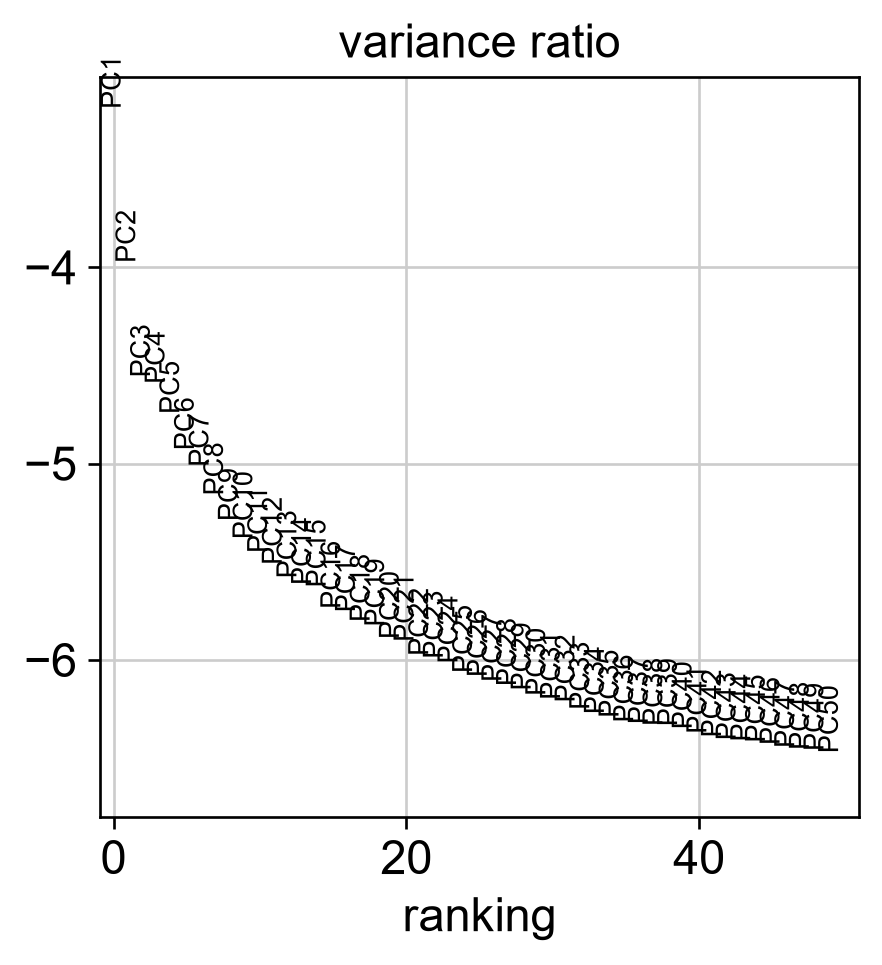

In [10]:
sc.tl.pca(adata_hvg, svd_solver="arpack", random_state=RANDOM_STATE)

# Carry PCA results back onto the full adata so downstream steps
# (neighbors/UMAP/Leiden/markers/DE) all operate on the same object.
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]
adata.varm = adata.varm if hasattr(adata, "varm") else {}

sc.pl.pca_variance_ratio(adata_hvg, log=True, n_pcs=50, save="_PCA_variance.png")

## 10. Neighbors, UMAP and Leiden

In [11]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=RANDOM_STATE)
sc.tl.umap(adata, random_state=RANDOM_STATE)

try:
    sc.tl.leiden(
        adata,
        resolution=0.8,
        key_added="leiden_res_0.8",
        flavor="igraph",
        n_iterations=2,
        random_state=RANDOM_STATE,
    )
except ImportError as e:
    raise ImportError(
        "Leiden clustering needs the 'igraph' package (or 'leidenalg' if you "
        "keep the default flavor), which isn't in the guide's original install "
        "list. Run in your terminal with the venv activated, then restart the "
        "kernel and re-run:\n"
        "    uv pip install igraph leidenalg"
    ) from e

n_clusters = adata.obs["leiden_res_0.8"].nunique()
print("Leiden clusters:", n_clusters)
print("Project guide target: approximately 36")

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:54)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:38)
running Leiden clustering
    finished: found 28 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:00:09)
Leiden clusters: 28
Project guide target: approximately 36


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\2852560353.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


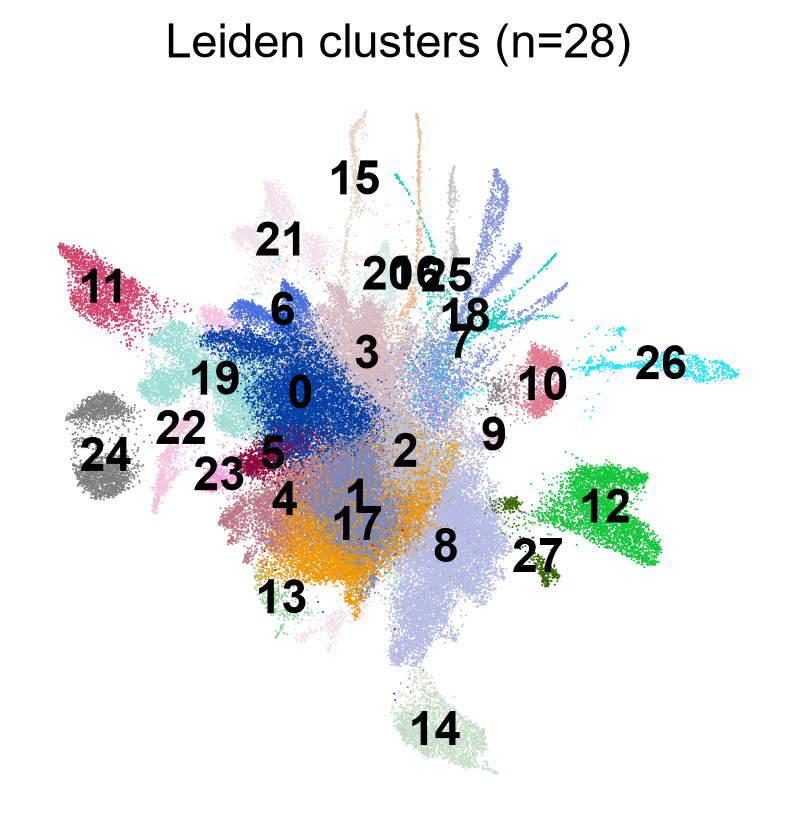

C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\2852560353.py:5: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=["sex", "treatment", "condition"], ncols=2, save="_Metadata_UMAP.png")


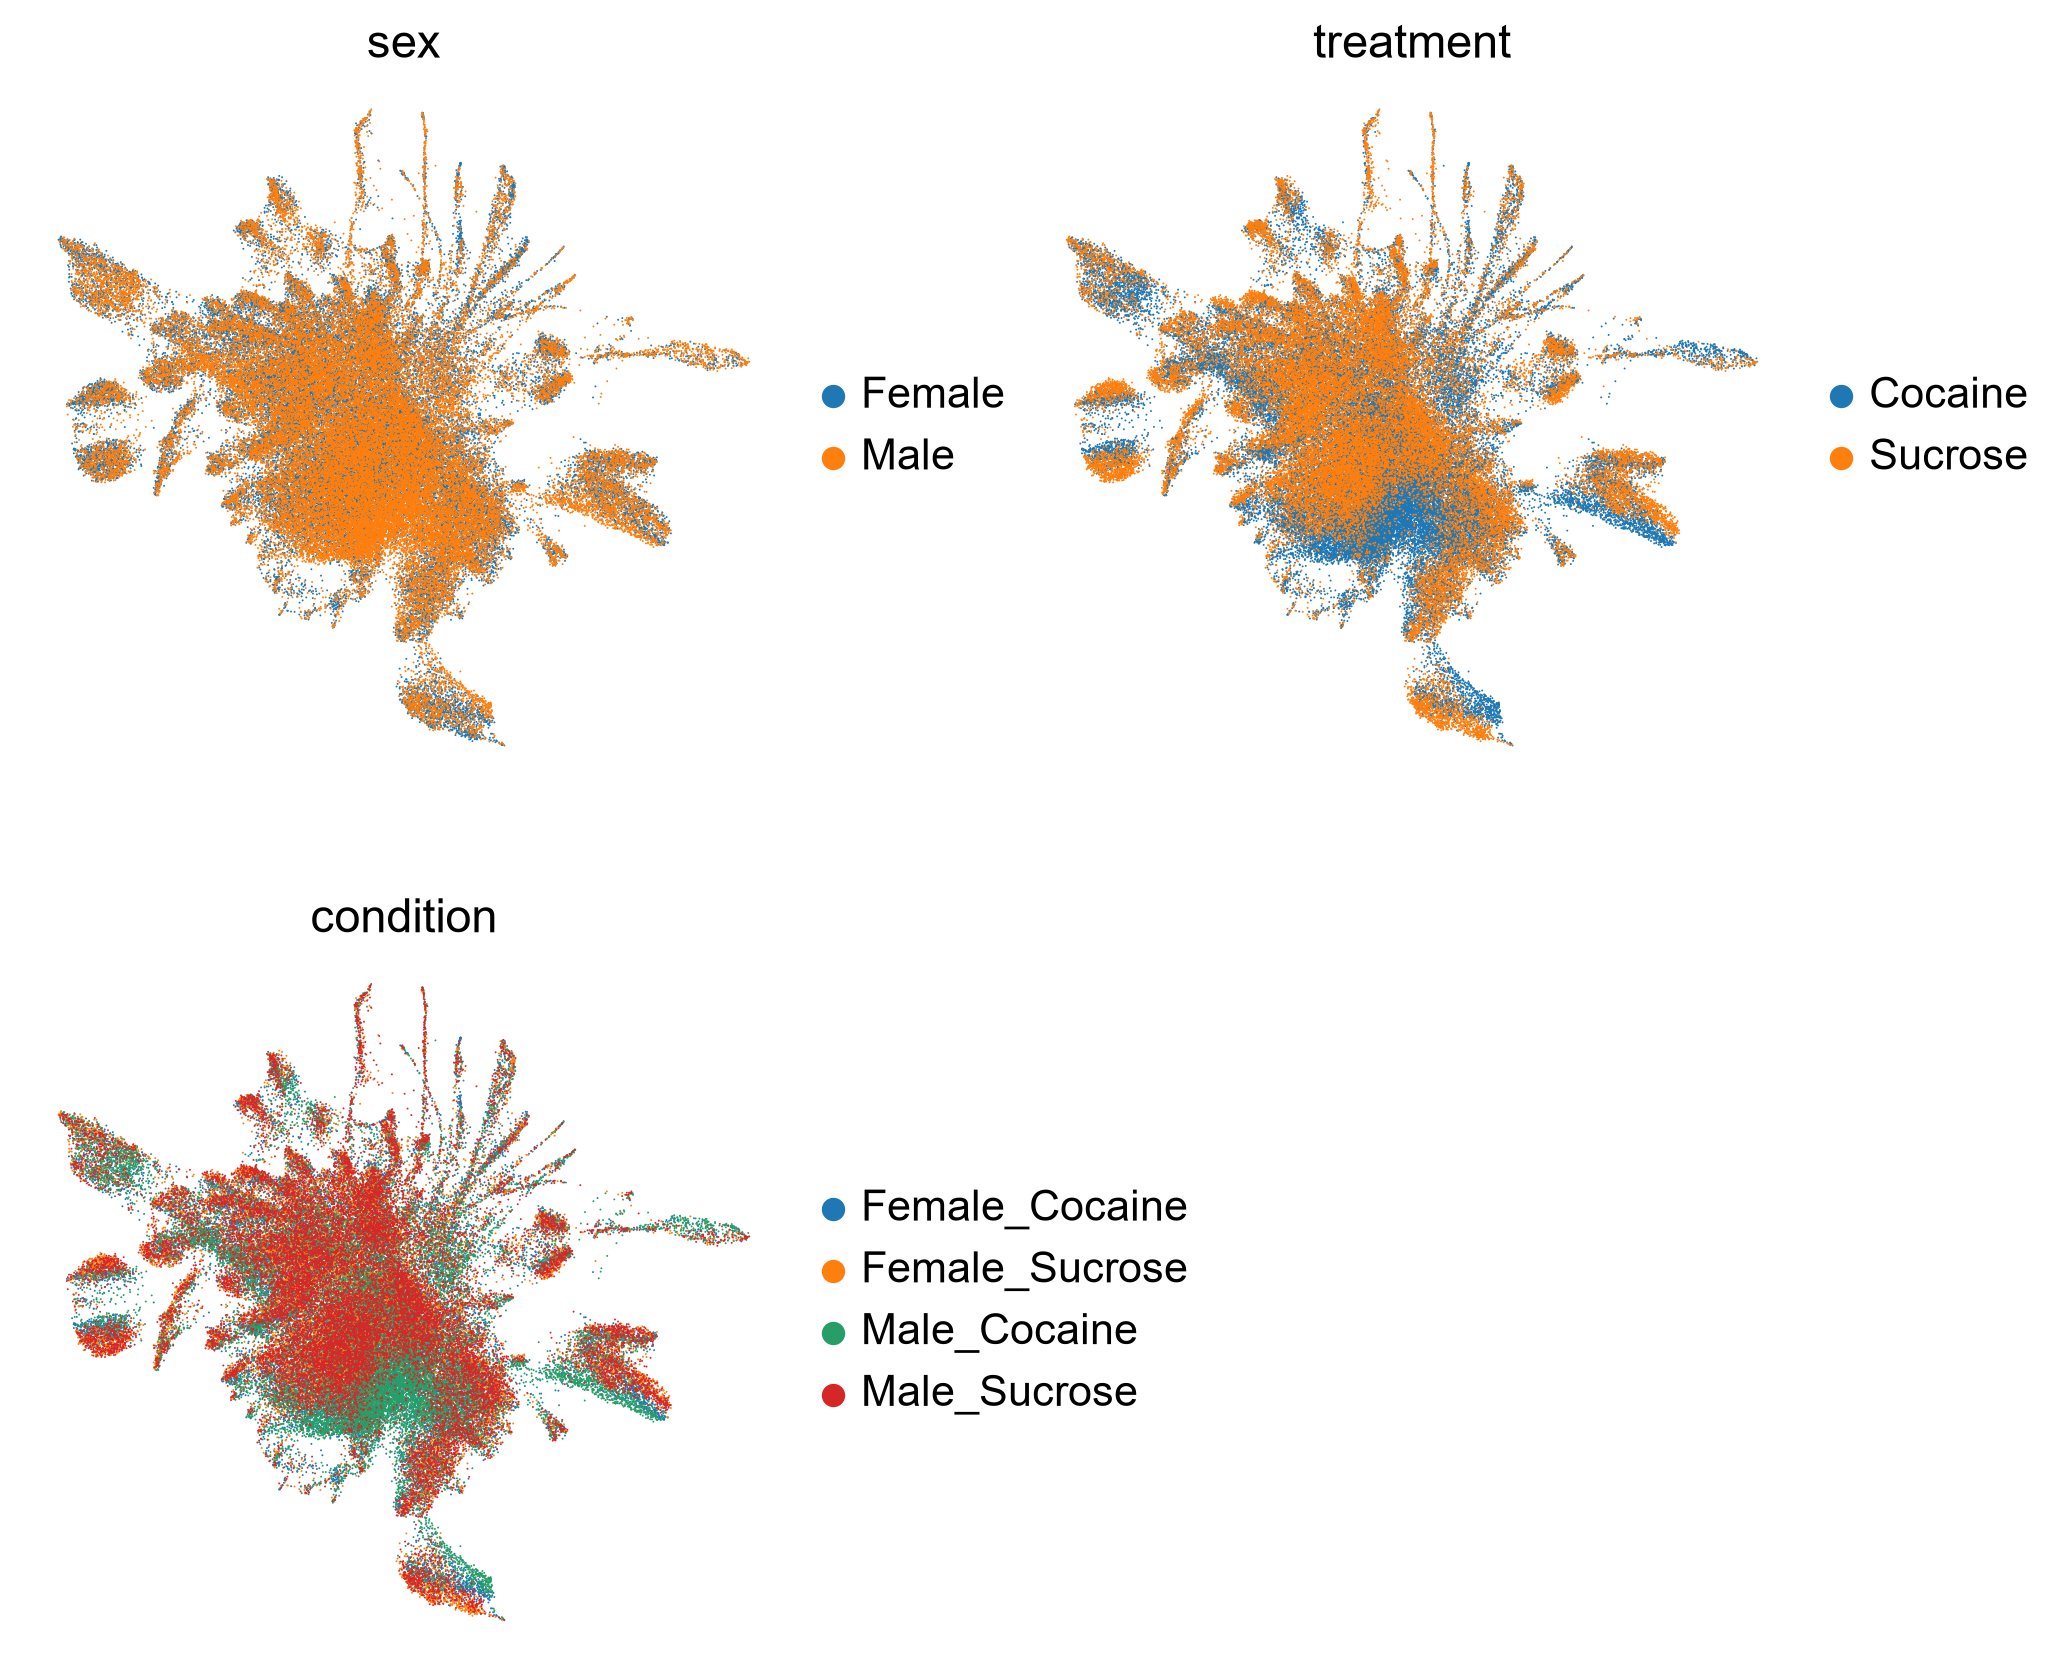

In [12]:
sc.pl.umap(
    adata, color="leiden_res_0.8", legend_loc="on data",
    title=f"Leiden clusters (n={n_clusters})", save="_Leiden_UMAP.png",
)
sc.pl.umap(adata, color=["sex", "treatment", "condition"], ncols=2, save="_Metadata_UMAP.png")

## 11. Cluster marker genes

In [13]:
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.8", method="wilcoxon")
cluster_markers = sc.get.rank_genes_groups_df(adata, group=None)
cluster_markers.to_csv(RESULT_DIR / "cluster_markers_wilcoxon.csv", index=False)

top10 = (cluster_markers.sort_values(["group", "scores"], ascending=[True, False])
         .groupby("group", observed=True).head(10))
top10.to_csv(RESULT_DIR / "top10_cluster_markers.csv", index=False)
display(top10.head(30))

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:03)


D:\bmp\sc_project2_drosophila_brain\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
D:\bmp\sc_project2_drosophila_brain\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:612: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
D:\bmp\sc_project2_drosophila_brain\.venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:622: PerformanceWarning: DataFram

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,lncRNA:mimi,49.037464,0.825056,0.000000e+00,0.000000e+00
1,0,Bacc,31.399944,0.279488,2.026967e-216,1.401914e-213
2,0,CG31221,31.044682,0.806081,1.345884e-211,8.422030e-209
3,0,lncRNA:roX2,30.551720,1.045589,5.365031e-205,3.204631e-202
4,0,VAChT,29.257030,0.791147,3.654641e-188,1.715201e-185
5,0,scrt,28.348417,0.330526,8.754751e-177,3.486248e-174
6,0,Cph,27.760918,1.340317,1.286476e-169,4.448836e-167
7,0,scro,26.995039,1.397871,1.690021e-160,5.047403e-158
8,0,lncRNA:roX1,25.635927,0.834341,6.068859e-145,1.399138e-142
9,0,CG42541,25.068699,0.614637,1.091912e-138,2.174062e-136


## 12. Canonical marker inspection

Available markers: ['repo', 'elav', 'ey', 'Fas2', 'VAChT', 'Gad1', 'ple', 'SerT', 'Tdc2']
Missing markers: ['VGlut']


C:\Users\Acer\AppData\Local\Temp\ipykernel_5720\3146597167.py:9: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, var_names=available_markers, groupby="leiden_res_0.8",


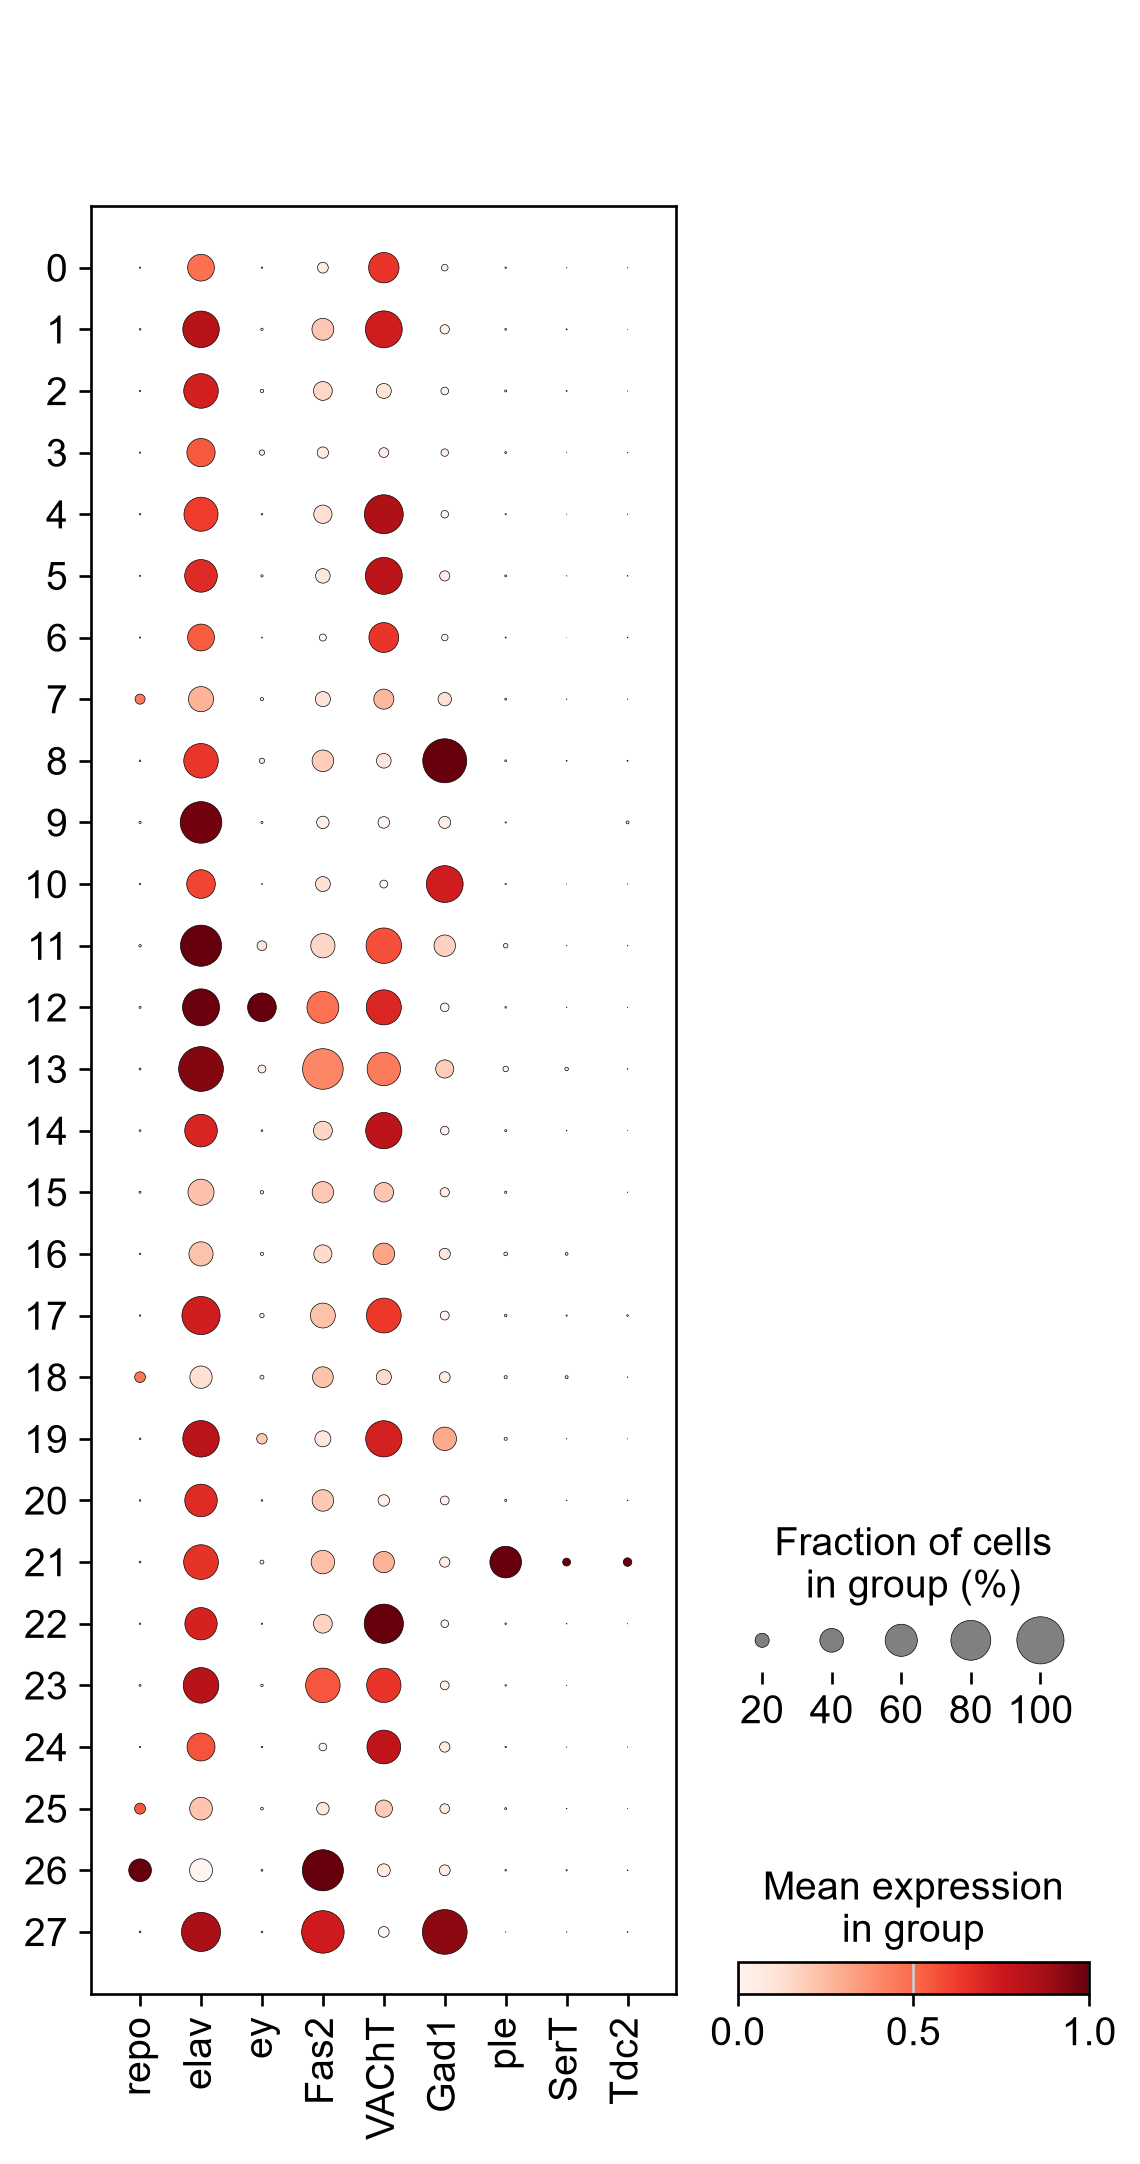

In [14]:
canonical_markers = ["repo", "elav", "ey", "Fas2", "VAChT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]
available_markers = [g for g in canonical_markers if g in adata.var_names]
missing_markers = [g for g in canonical_markers if g not in adata.var_names]

print("Available markers:", available_markers)
print("Missing markers:", missing_markers)

if available_markers:
    sc.pl.dotplot(adata, var_names=available_markers, groupby="leiden_res_0.8",
                  standard_scale="var", save="_Canonical_markers.png")

## 13. Annotation template

In [15]:
clusters = sorted(adata.obs["leiden_res_0.8"].astype(str).unique(), key=int)
annotation_template = pd.DataFrame({
    "cluster": clusters, "cell_type": ["Unassigned"] * len(clusters),
    "evidence_markers": [""] * len(clusters), "notes": [""] * len(clusters),
})
display(annotation_template)
annotation_template.to_csv(RESULT_DIR / "cluster_annotation_template.csv", index=False)

,cluster,cell_type,evidence_markers,notes
0,0,Unassigned,,
1,1,Unassigned,,
2,2,Unassigned,,
3,3,Unassigned,,
4,4,Unassigned,,
5,5,Unassigned,,
6,6,Unassigned,,
7,7,Unassigned,,
8,8,Unassigned,,
9,9,Unassigned,,


## 14. Male vs female differential expression

In [16]:
def sex_specific_de(adata_all, sex_name):
    subset = adata_all[adata_all.obs["sex"].astype(str) == sex_name].copy()
    sc.tl.rank_genes_groups(subset, groupby="treatment", reference="Sucrose", method="wilcoxon")
    de = sc.get.rank_genes_groups_df(subset, group="Cocaine")
    de["significant"] = de["logfoldchanges"].abs().gt(1.0) & de["pvals_adj"].lt(0.05)
    return subset, de

adata_male, male_de = sex_specific_de(adata, "Male")
adata_female, female_de = sex_specific_de(adata, "Female")

male_sig = male_de[male_de["significant"]].copy()
female_sig = female_de[female_de["significant"]].copy()

print("Male significant genes:", len(male_sig))
print("Female significant genes:", len(female_sig))

male_de.to_csv(RESULT_DIR / "male_Cocaine_vs_Sucrose_all_DE.csv", index=False)
female_de.to_csv(RESULT_DIR / "female_Cocaine_vs_Sucrose_all_DE.csv", index=False)
male_sig.to_csv(RESULT_DIR / "male_Cocaine_vs_Sucrose_significant_DE.csv", index=False)
female_sig.to_csv(RESULT_DIR / "female_Cocaine_vs_Sucrose_significant_DE.csv", index=False)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:33)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:23)
Male significant genes: 89
Female significant genes: 171


## 15. Male/female DE overlap

In [17]:
male_genes = set(male_sig["names"].astype(str))
female_genes = set(female_sig["names"].astype(str))
shared_genes = sorted(male_genes & female_genes)
male_only = sorted(male_genes - female_genes)
female_only = sorted(female_genes - male_genes)

overlap = pd.DataFrame({"category": ["Male-only", "Female-only", "Shared"],
                         "n_genes": [len(male_only), len(female_only), len(shared_genes)]})
display(overlap)

pd.DataFrame({"gene": shared_genes}).to_csv(RESULT_DIR / "shared_DE_genes.csv", index=False)
pd.DataFrame({"gene": male_only}).to_csv(RESULT_DIR / "male_only_DE_genes.csv", index=False)
pd.DataFrame({"gene": female_only}).to_csv(RESULT_DIR / "female_only_DE_genes.csv", index=False)

,category,n_genes
0,Male-only,52
1,Female-only,134
2,Shared,37


## 16. Volcano plots (fixed label overlap)

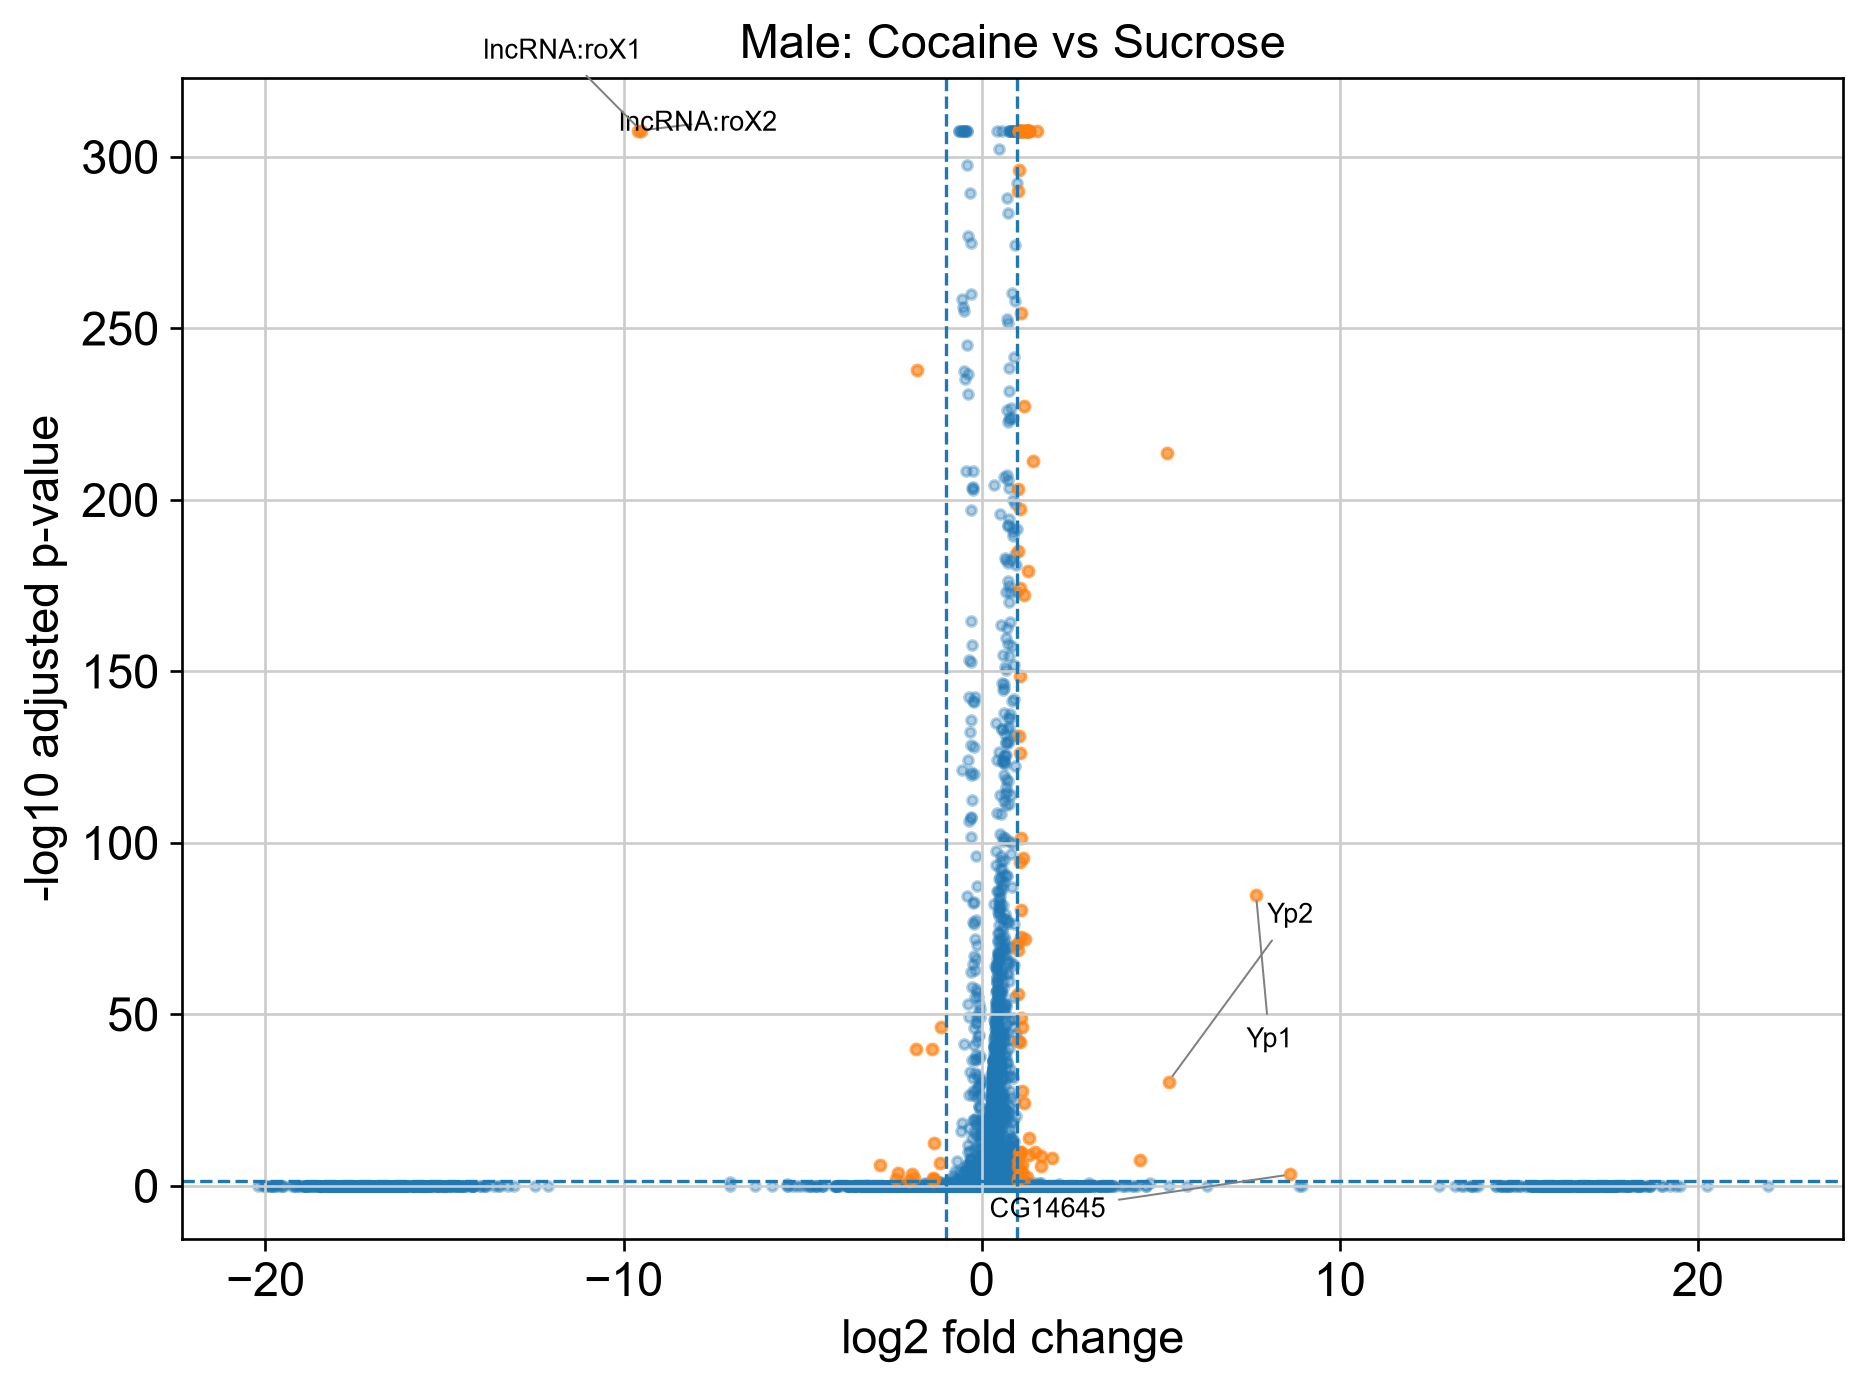

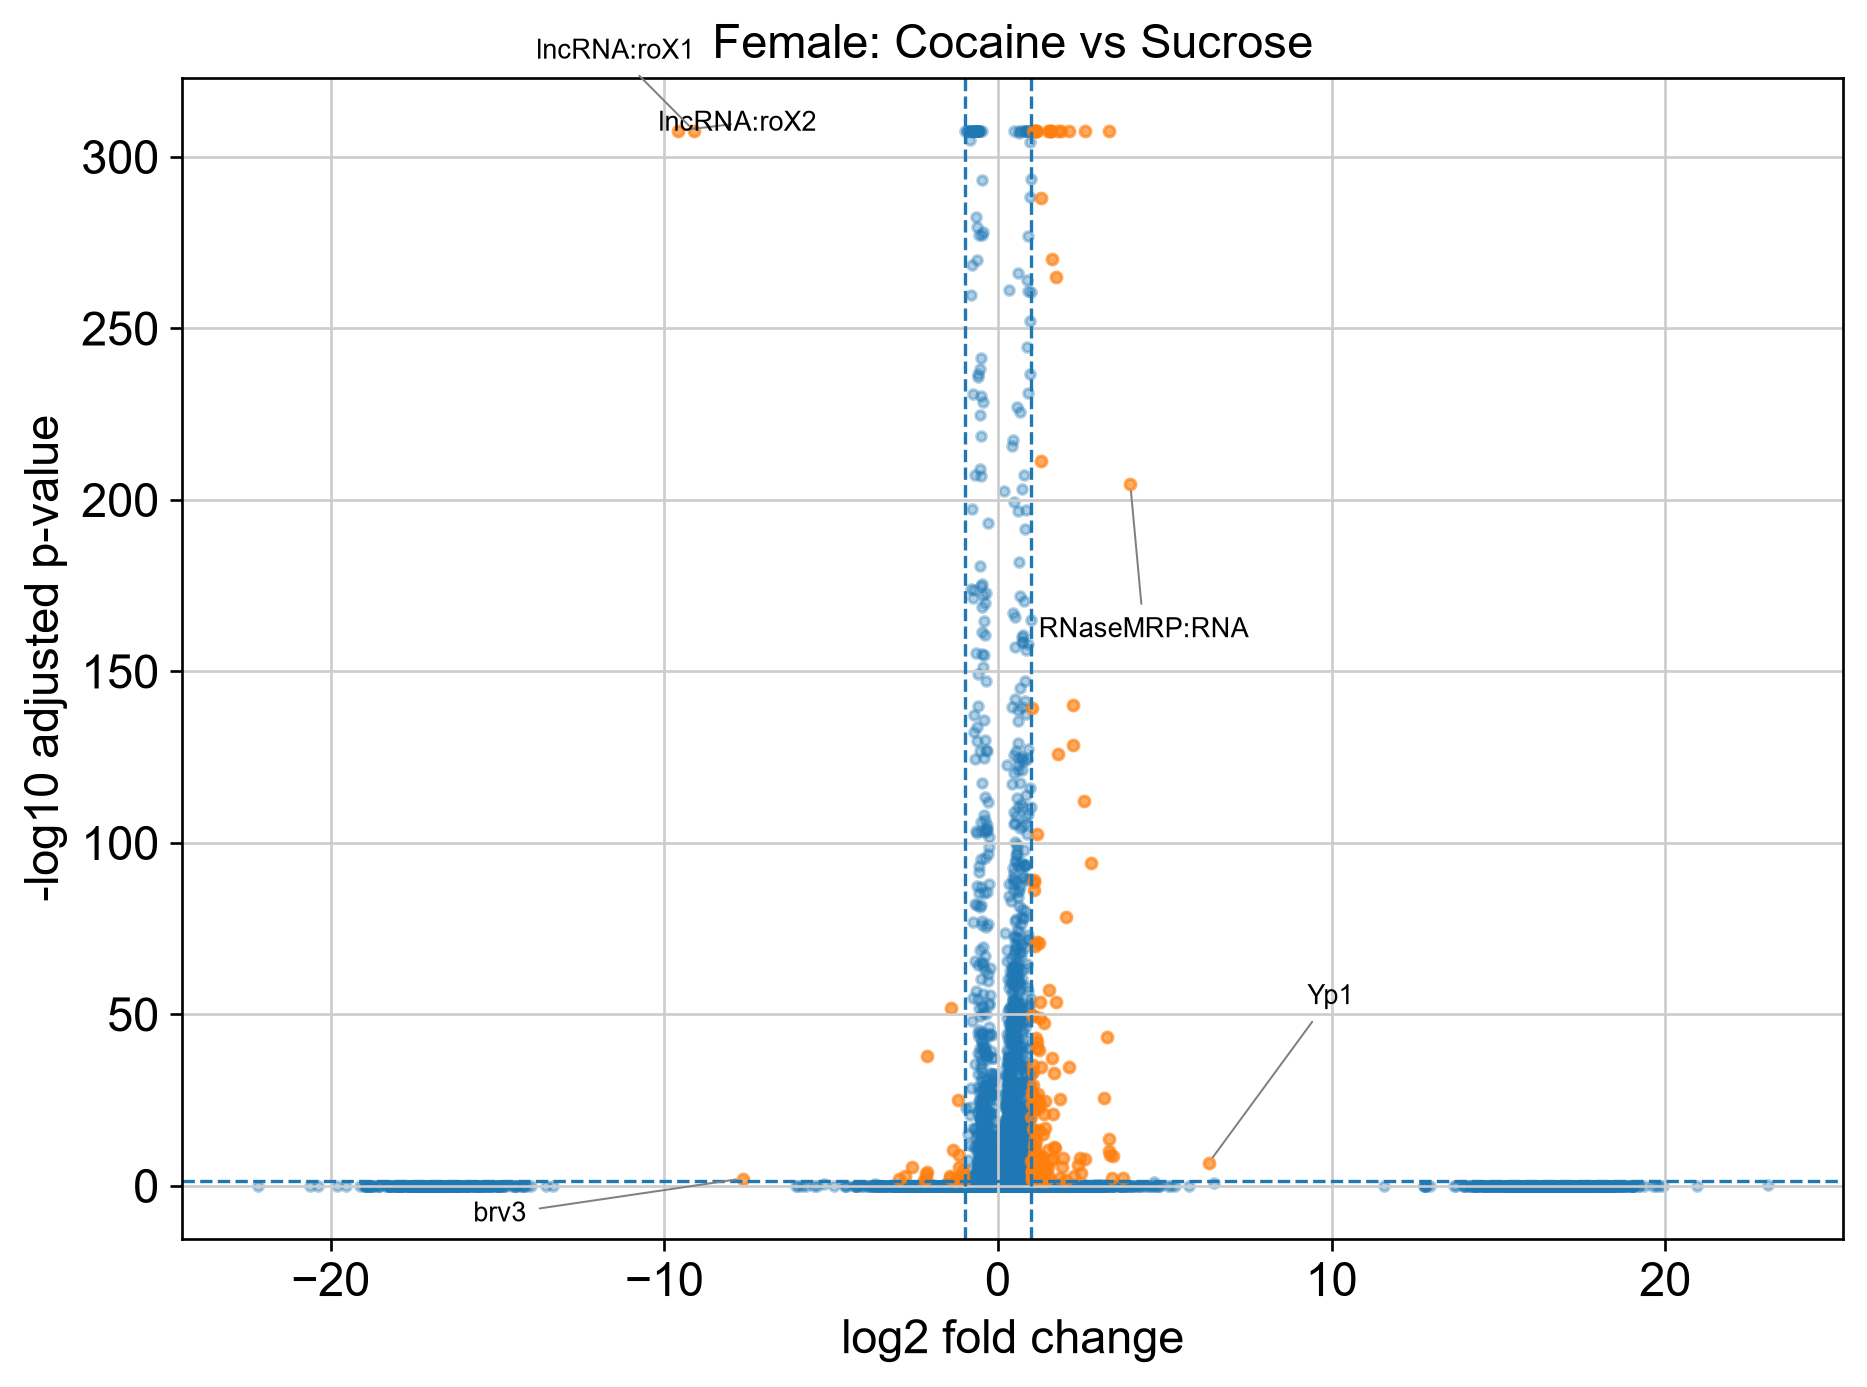

In [22]:
def volcano(de, title, filename, label_top_n=5):
    import math

    df = de.copy()
    df["neglog10_padj"] = -np.log10(df["pvals_adj"].clip(lower=np.finfo(float).tiny))
    sig = df["logfoldchanges"].abs().gt(1) & df["pvals_adj"].lt(0.05)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df.loc[~sig, "logfoldchanges"], df.loc[~sig, "neglog10_padj"], s=8, alpha=0.35)
    ax.scatter(df.loc[sig, "logfoldchanges"], df.loc[sig, "neglog10_padj"], s=10, alpha=0.65)
    ax.axvline(1, ls="--", lw=1); ax.axvline(-1, ls="--", lw=1)
    ax.axhline(-np.log10(0.05), ls="--", lw=1)

    label_df = df.loc[sig].reindex(df.loc[sig, "logfoldchanges"].abs().sort_values(ascending=False).index)
    label_df = label_df.head(label_top_n).sort_values("neglog10_padj", ascending=False).reset_index(drop=True)

    # Several top hits often sit at nearly the same (x, y) - e.g. tied at the
    # p-value floor - so a fixed offset direction still overlaps. Instead,
    # place each label at a different angle/radius (golden-angle spiral) so
    # labels never stack, and draw a thin connector line back to its point.
    golden_angle = 137.508
    base_radius = 18
    for i, row in label_df.iterrows():
        angle_rad = math.radians((i * golden_angle) % 360)
        radius = base_radius + 14 * i
        dx = radius * math.cos(angle_rad)
        dy = radius * math.sin(angle_rad)
        ax.annotate(
            str(row["names"]),
            xy=(row["logfoldchanges"], row["neglog10_padj"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8,
            ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.6, color="gray", shrinkA=2, shrinkB=2),
        )

    ax.set_xlabel("log2 fold change"); ax.set_ylabel("-log10 adjusted p-value"); ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

volcano(male_de, "Male: Cocaine vs Sucrose", "Male_Volcano.png")
volcano(female_de, "Female: Cocaine vs Sucrose", "Female_Volcano.png")

## 17. Pathway enrichment

In [19]:
try:
    import gseapy as gp
    print("GSEApy:", gp.__version__)
except Exception:
    gp = None
    print("GSEApy is unavailable. Install it with: uv add gseapy")


def enrich(sig_df, label):
    if gp is None:
        return None
    genes = sig_df["names"].astype(str).drop_duplicates().tolist()[:150]
    if not genes:
        print(f"No significant genes for {label}")
        return None
    try:
        fly_libraries = gp.get_library_name(organism="Fly")
        go_bp = [x for x in fly_libraries if "GO_Biological_Process" in x]
        kegg = [x for x in fly_libraries if "KEGG" in x]
        gene_sets = go_bp[-1:] + kegg[-1:]
        print(f"{label}: using {gene_sets}")

        result = gp.enrichr(gene_list=genes, gene_sets=gene_sets, organism="fly", outdir=None)
        result.results.to_csv(RESULT_DIR / f"{label.lower()}_enrichment_results.csv", index=False)
        return result
    except Exception as e:
        print(f"Enrichment failed for {label}: {e}")
        return None

enr_male = enrich(male_sig, "Male")
enr_female = enrich(female_sig, "Female")

GSEApy: 1.3.1
Male: using ['GO_Biological_Process_GeneRIF_Predicted_zscore', 'KEGG_2019']
Female: using ['GO_Biological_Process_GeneRIF_Predicted_zscore', 'KEGG_2019']


## 18. Enrichment bar charts (with significance threshold shown)



Male: 1 of top 10 shown terms pass adjusted p < 0.05


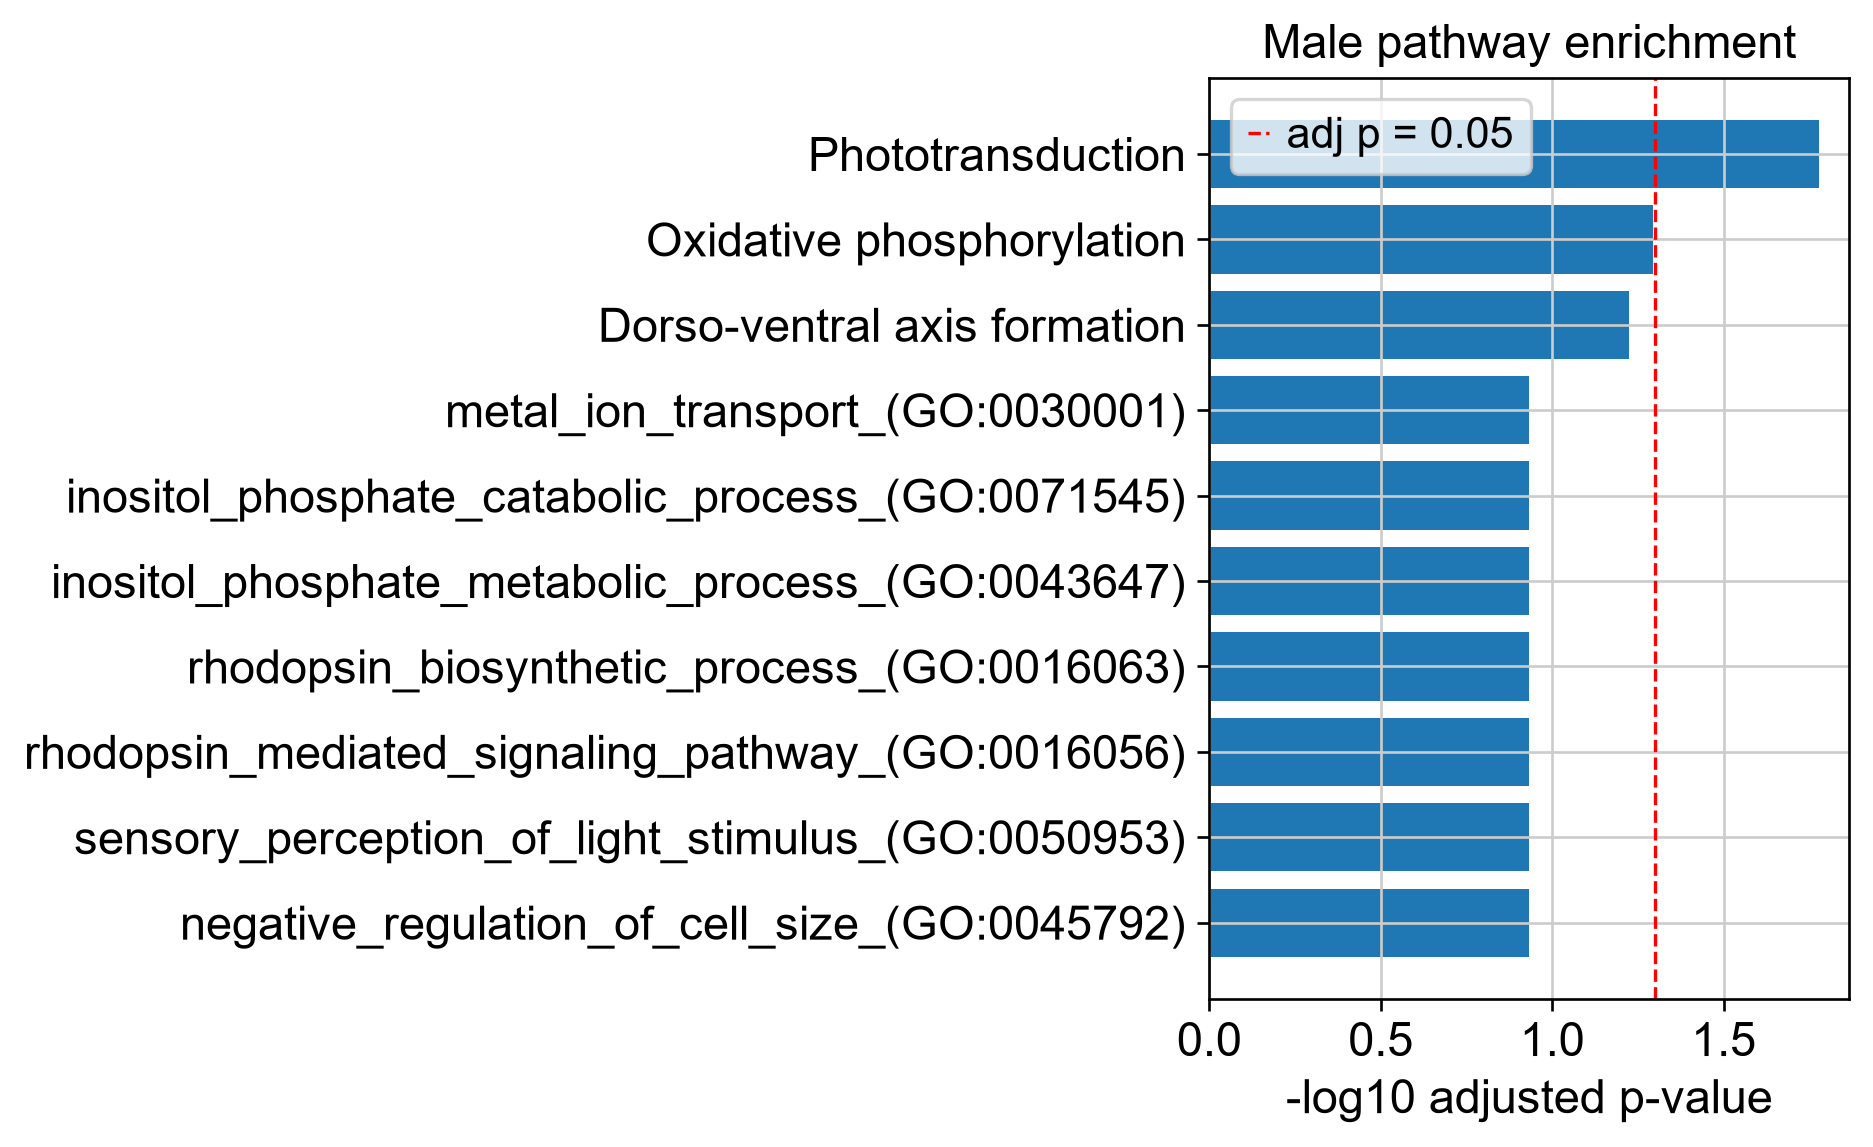

Saved: D:\bmp\sc_project2_drosophila_brain\figures\male_pathway_enrichment.png
Female: 0 of top 10 shown terms pass adjusted p < 0.05


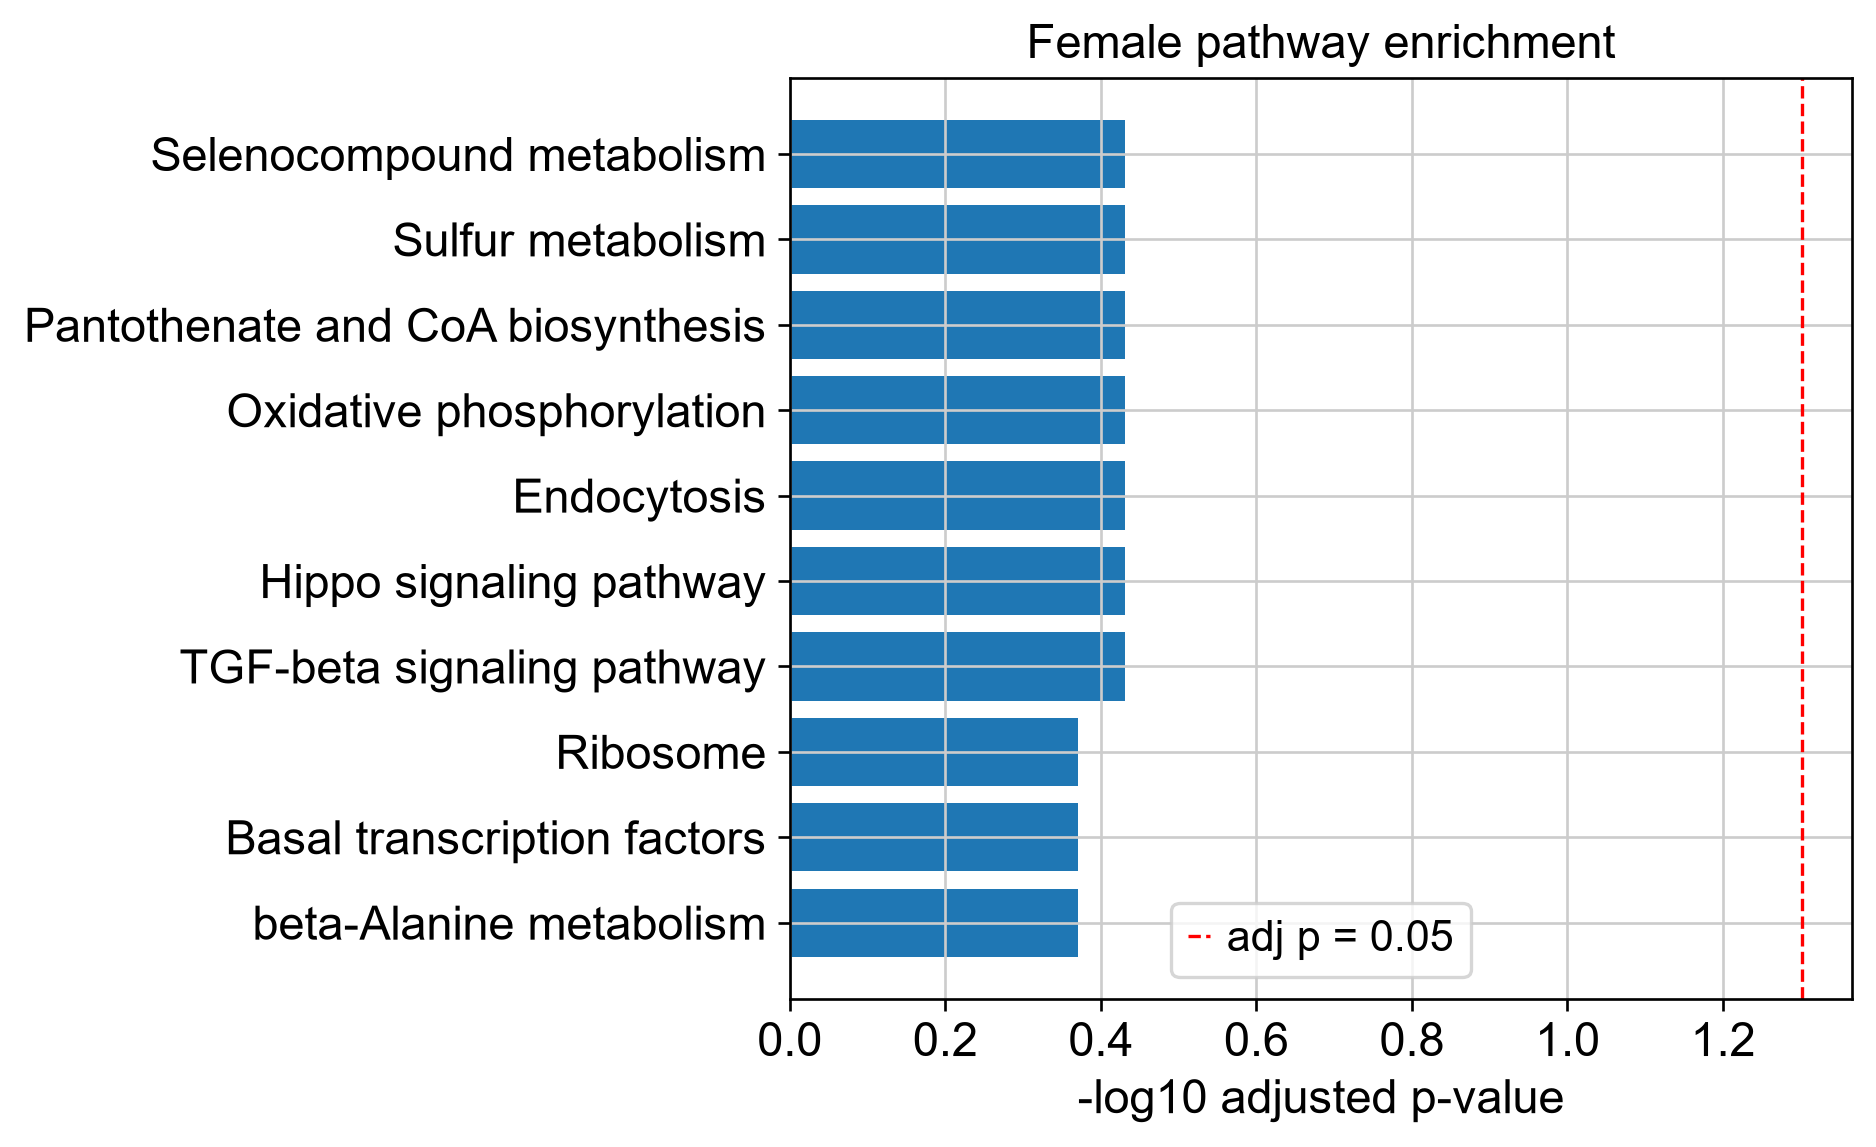

Saved: D:\bmp\sc_project2_drosophila_brain\figures\female_pathway_enrichment.png


In [20]:
for sex in ["male", "female"]:
    file = RESULT_DIR / f"{sex}_enrichment_results.csv"
    if not file.exists():
        print(f"No enrichment results file for {sex}, skipping.")
        continue

    df = pd.read_csv(file)
    df = df.dropna(subset=["Term", "Adjusted P-value"])
    df = df[df["Adjusted P-value"] > 0].sort_values("Adjusted P-value").head(10)
    df["neglog10_padj"] = -np.log10(df["Adjusted P-value"])

    n_significant = int((df["Adjusted P-value"] < 0.05).sum())
    print(f"{sex.capitalize()}: {n_significant} of top {len(df)} shown terms pass adjusted p < 0.05")

    plt.figure(figsize=(8, 5))
    plt.barh(df["Term"].iloc[::-1], df["neglog10_padj"].iloc[::-1])
    plt.axvline(-np.log10(0.05), color="red", ls="--", lw=1, label="adj p = 0.05")
    plt.xlabel("-log10 adjusted p-value")
    plt.title(f"{sex.capitalize()} pathway enrichment")
    plt.legend()
    plt.tight_layout()

    output = FIG_DIR / f"{sex}_pathway_enrichment.png"
    plt.savefig(output, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output.resolve())

## 19. Final summary and export

In [21]:
summary = pd.DataFrame({
    "metric": ["cells_after_QC", "genes_after_QC", "HVGs", "Leiden_clusters",
               "male_significant_DE_genes", "female_significant_DE_genes", "shared_DE_genes"],
    "value": [adata.n_obs, adata.n_vars, int(adata.var["highly_variable"].sum()),
              adata.obs["leiden_res_0.8"].nunique(), len(male_sig), len(female_sig), len(shared_genes)],
})
display(summary)
summary.to_csv(RESULT_DIR / "final_analysis_summary.csv", index=False)
adata.write(RESULT_DIR / "adata_final.h5ad")

print("✓ Final AnnData:", RESULT_DIR / "adata_final.h5ad")
print("✓ Figures:", FIG_DIR)
print("✓ Results:", RESULT_DIR)

,metric,value
0,cells_after_QC,88923
1,genes_after_QC,13141
2,HVGs,2000
3,Leiden_clusters,28
4,male_significant_DE_genes,89
5,female_significant_DE_genes,171
6,shared_DE_genes,37


✓ Final AnnData: D:\bmp\sc_project2_drosophila_brain\results\adata_final.h5ad
✓ Figures: D:\bmp\sc_project2_drosophila_brain\figures
✓ Results: D:\bmp\sc_project2_drosophila_brain\results
